# Affordance Matrix Experiments

## Overview
This notebook tests how different affordance weight matrices affect task performance across developmental stages. The affordance matrices control the mapping from perceptual working-memory features to motor actions (reach, grasp, rotate, translate).

### Questions
- How does the structure of the affordance-to-action mapping change task success rates across infant developmental profiles?
- Which matrix variant best supports the task at each 'age'?

12 trials per condition (for stable averages)

### Interpretation
- Higher **success rate** = matrix better supports task completion
- Lower **mean timesteps** = faster task execution
- Higher **efficiency** = more direct path to goal (less backtracking)
- Lower **mean_pos_error** and **mean_angle_error** = more accurate final pose
- **Example trajectories** show qualitative path shapes and strategies

In [ ]:
from dataclasses import replace
from html import escape
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

# Support running from either the repository root or the gaze_model folder.
cwd = Path.cwd()
if (cwd / "planning_cascade_model.py").exists():
    sys.path.insert(0, str(cwd))
elif (cwd / "gaze_model" / "planning_cascade_model.py").exists():
    sys.path.insert(0, str(cwd / "gaze_model"))

from affordance_matrices import ACTION_LABELS, AFFORDANCE_MATRIX_VARIANTS, FEATURE_LABELS
from model_utils import DevelopmentalParams, TaskConfig
from planning_cascade_model import run_trial

In [10]:
# Developmental stages
# Define the four profiles used in this experiment

DEVELOPMENTAL_STAGES = {
    "A": DevelopmentalParams(
        name="A",
        gaze_switch_rate=0.12, fixation_duration_mean=5.0, target_bias=0.20,
        simultaneous_rate=0.03, sampling_rate=0.30, perceptual_noise=0.35,
        location_acuity=0.70, orientation_acuity=0.15, relation_acuity=0.05,
        wm_capacity=2, wm_decay=0.18, wm_unfixated_decay=0.40,
        affordance_coupling=0.25, affordance_noise=0.25, planning_horizon=1,
        motor_noise=0.20, habit_strength=0.78, goal_directed_strength=0.22,
        correction_rate=0.12, correction_delay=2, initiation_threshold=0.15,
    ),
    "B": DevelopmentalParams(
        name="B",
        gaze_switch_rate=0.25, fixation_duration_mean=3.5, target_bias=0.35,
        simultaneous_rate=0.12, sampling_rate=0.45, perceptual_noise=0.28,
        location_acuity=0.85, orientation_acuity=0.30, relation_acuity=0.12,
        wm_capacity=3, wm_decay=0.12, wm_unfixated_decay=0.28,
        affordance_coupling=0.40, affordance_noise=0.22, planning_horizon=2,
        motor_noise=0.22, habit_strength=0.70, goal_directed_strength=0.30,
        correction_rate=0.14, correction_delay=2, initiation_threshold=0.28,
    ),
    "C": DevelopmentalParams(
        name="C",
        gaze_switch_rate=0.40, fixation_duration_mean=2.5, target_bias=0.50,
        simultaneous_rate=0.28, sampling_rate=0.65, perceptual_noise=0.16,
        location_acuity=0.93, orientation_acuity=0.55, relation_acuity=0.30,
        wm_capacity=4, wm_decay=0.08, wm_unfixated_decay=0.18,
        affordance_coupling=0.60, affordance_noise=0.14, planning_horizon=4,
        motor_noise=0.16, habit_strength=0.40, goal_directed_strength=0.60,
        correction_rate=0.22, correction_delay=1, initiation_threshold=0.40,
    ),
    "D": DevelopmentalParams(
        name="D",
        gaze_switch_rate=0.55, fixation_duration_mean=2.0, target_bias=0.60,
        simultaneous_rate=0.50, sampling_rate=0.85, perceptual_noise=0.08,
        location_acuity=0.98, orientation_acuity=0.88, relation_acuity=0.55,
        wm_capacity=5, wm_decay=0.04, wm_unfixated_decay=0.10,
        affordance_coupling=0.85, affordance_noise=0.08, planning_horizon=6,
        motor_noise=0.08, habit_strength=0.10, goal_directed_strength=0.90,
        correction_rate=0.28, correction_delay=0, initiation_threshold=0.45,
    ),
}

# Define the task: medium distance with a 1.2 rad rotation required
EXPERIMENT_TASK = TaskConfig(
    name="medium_rotated",
    start_x=0.0, start_y=0.0, start_angle=0.0,
    goal_x=0.5, goal_y=0.0, goal_angle=1.2,
    obj_width=0.3, obj_height=0.6, max_timesteps=120,
)

STAGE_NAMES = list(DEVELOPMENTAL_STAGES)
VARIANTS = list(AFFORDANCE_MATRIX_VARIANTS)

# Number of simulated trials per condition (stage × variant)
N_TRIALS = 25
SEED = 100

In [11]:
# Visualisation things
STAGE_COLOURS = ["#0584CD", "#E76C1F", "#7C0DC2", "#6A6A6A"]
VARIANT_COLOURS = ["#0584CD", "#7C0DC2", "#E76C1F", "#666666", "#56B4E9", "#999999"]
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

## Helper Functions
For data collection, aggregation, and visualisation

In [12]:
def format_cell(value):
    """Format table cells for compact HTML display."""
    if isinstance(value, float):
        return f"{value:.3f}"
    return escape(str(value))


def rows_to_html(rows, columns):
    """Render a list of dictionaries as a small HTML table."""
    header = "".join(f"<th>{escape(column)}</th>" for column in columns)
    body_rows = []
    for row in rows:
        cells = "".join(f"<td>{format_cell(row[column])}</td>" for column in columns)
        body_rows.append(f"<tr>{cells}</tr>")
    table_style = "border-collapse: collapse; font-family: sans-serif; font-size: 13px;"
    cell_style = "th, td { border: 1px solid #ddd; padding: 4px 7px; text-align: right; } th:first-child, td:first-child { text-align: left; }"
    return f"<style>{cell_style}</style><table style='{table_style}'><thead><tr>{header}</tr></thead><tbody>{''.join(body_rows)}</tbody></table>"


def run_variant_batch(stage_names, task, variants, n_trials, seed):
    """Run every affordance matrix variant across stages and trials.

    Args:
        stage_names: List of developmental stage names (e.g., ['A', 'B', 'C', 'D'])
        task: TaskConfig object describing the task geometry
        variants: List of affordance matrix variant names
        n_trials: Number of trials per (stage, variant) combination
        seed: Random seed for reproducibility

    Returns:
        rows: List of dicts with trial-level data (one per trial)
        examples: Dict of first-trial results keyed by (variant, stage_name)
    """
    rows = []
    examples = {}
    for stage_name in stage_names:
        base_params = DEVELOPMENTAL_STAGES[stage_name]
        for variant in variants:
            params = replace(
                base_params,
                name=f"{stage_name}_{variant}",
                affordance_matrix_variant=variant,
            )
            for trial_index in range(n_trials):
                result = run_trial(params, task, seed=seed + trial_index, trial_id=trial_index)
                if trial_index == 0:
                    examples[(variant, stage_name)] = result
                rows.append({
                    "variant": variant,
                    "stage": stage_name,
                    "task": task.name,
                    "trial": trial_index,
                    "success": float(result.success),
                    "timesteps": result.timesteps_used,
                    "pos_error": float(result.final_pos_error),
                    "angle_error": float(result.final_angle_error),
                    "efficiency": float(result.efficiency),
                    "movement_onset": result.movement_onset,
                    "gaze_switches": result.total_gaze_switches,
                })
    return rows, examples


def summarise_rows(rows, variants, stage_names):
    """Aggregate trial rows by variant and stage."""
    summary = []
    for variant in variants:
        for stage_name in stage_names:
            group = [row for row in rows if row["variant"] == variant and row["stage"] == stage_name]
            summary.append({
                "variant": variant,
                "stage": stage_name,
                "n_trials": len(group),
                "success_rate": float(np.mean([row["success"] for row in group])),
                "mean_timesteps": float(np.mean([row["timesteps"] for row in group])),
                "mean_pos_error": float(np.mean([row["pos_error"] for row in group])),
                "mean_angle_error": float(np.mean([row["angle_error"] for row in group])),
                "mean_efficiency": float(np.mean([row["efficiency"] for row in group])),
                "mean_movement_onset": float(np.mean([row["movement_onset"] for row in group])),
                "mean_gaze_switches": float(np.mean([row["gaze_switches"] for row in group])),
            })
    return summary


def plot_affordance_matrices(variants):
    """Display each matrix as a heatmap with shared row/column labels."""
    fig, axes = plt.subplots(1, len(variants), figsize=(4.2 * len(variants), 5.5), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, variant in zip(axes, variants):
        image = ax.imshow(AFFORDANCE_MATRIX_VARIANTS[variant], vmin=0, vmax=1, cmap="viridis")
        ax.set_title(variant)
        ax.set_xticks(range(len(ACTION_LABELS)))
        ax.set_xticklabels(ACTION_LABELS, rotation=35, ha="right")
        ax.set_yticks(range(len(FEATURE_LABELS)))
        ax.set_yticklabels(FEATURE_LABELS)
    fig.colorbar(image, ax=axes, shrink=0.75, label="weight")
    plt.show()


def plot_metric_by_stage(summary, variants, stage_names, metric, ylabel):
    """Plot a metric for every variant, split by developmental stage."""
    x = np.arange(len(variants))
    width = 0.8 / len(stage_names)
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for stage_index, stage_name in enumerate(stage_names):
        color = STAGE_COLOURS[stage_index % len(STAGE_COLOURS)]
        values = [next(row[metric] for row in summary if row["variant"] == variant and row["stage"] == stage_name) for variant in variants]
        offset = (stage_index - (len(stage_names) - 1) / 2) * width
        ax.bar(x + offset, values, width=width, label=stage_name, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + " by affordance matrix variant")
    ax.legend(title="Stage", fontsize=8)
    ax.grid(axis="y", alpha=0.25)
    plt.show()


def plot_example_trajectories(examples, variants, stage_name, task):
    """Plot one example trajectory per matrix variant for a selected stage.

    Args:
        examples: dict keyed by (variant, stage_name) → TrialResult
        variants: list of variant names
        stage_name: which stage to display
        task: TaskConfig (used for start/goal markers and title)
    """
    fig, ax = plt.subplots(figsize=(6, 5.5))
    for variant_index, variant in enumerate(variants):
        color = VARIANT_COLOURS[variant_index % len(VARIANT_COLOURS)]
        trajectory = examples[(variant, stage_name)].trajectory
        ax.plot(
            [step.obj_x for step in trajectory],
            [step.obj_y for step in trajectory],
            marker="o", markersize=2.5, label=variant, color=color,
        )

    ax.scatter([task.start_x], [task.start_y], c="black", marker="x", s=70, label="start")
    ax.scatter([task.goal_x], [task.goal_y], c="gold", edgecolors="black", s=90, label="goal")

    ax.set_title(f"Example trajectories: {task.name}, stage {stage_name}")
    ax.set_xlabel("object x")
    ax.set_ylabel("object y")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    plt.show()

## Matrix Definitions
Higher values mean perceiving a feature creates stronger pressure to execute that action, before developmental parameters and motor noise are applied.

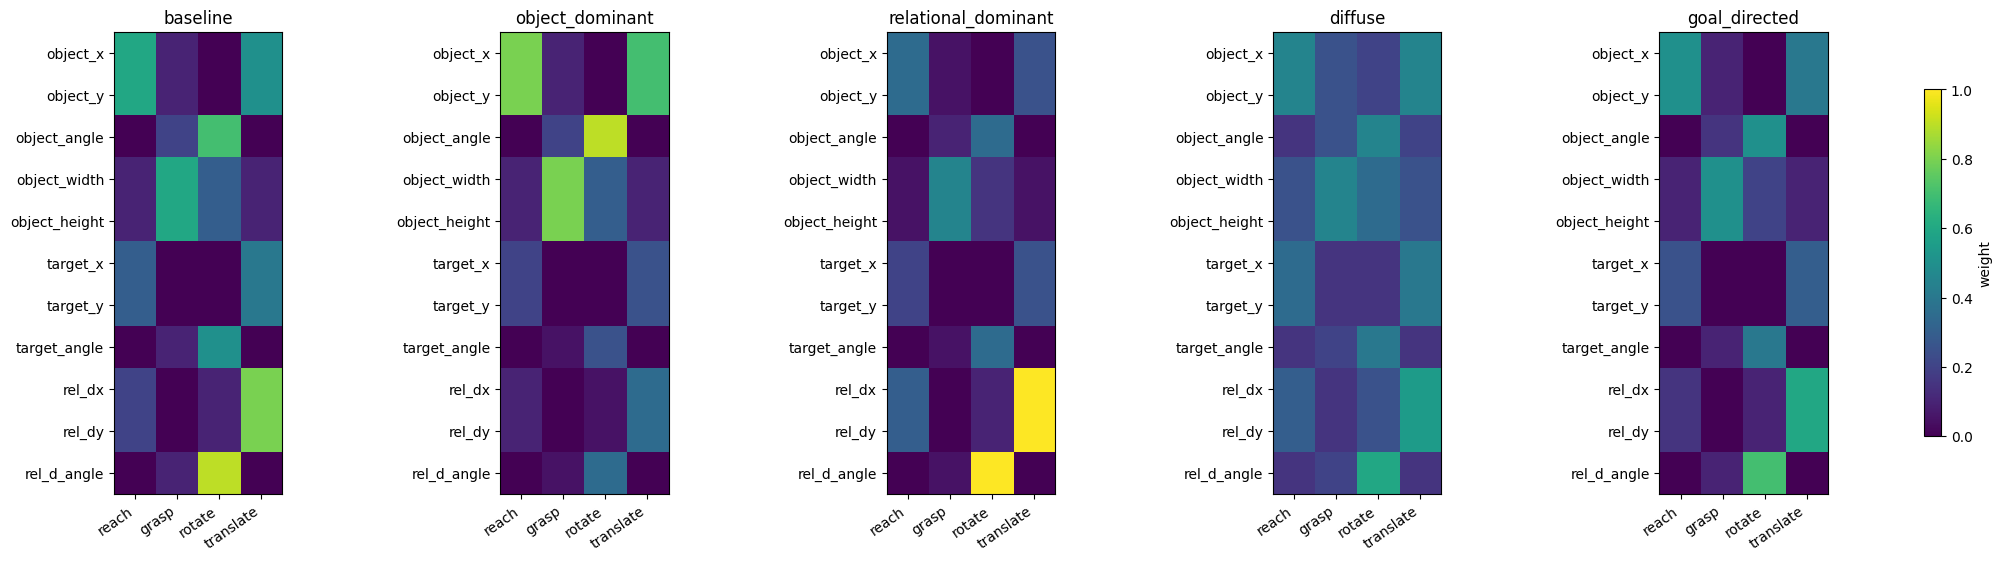

In [13]:
plot_affordance_matrices(VARIANTS)

## Run Experiments

- success_rate: Proportion of trials where the object was successfully inserted within position and angle tolerance
- mean_timesteps: Average number of simulation steps to complete the task (or timeout at 120 steps)
- mean_pos_error: Final Euclidean distance from goal (lower is better)
- mean_angle_error: Final angular difference from goal orientation (lower is better)
- mean_efficiency: Path efficiency ratio of optimal distance / actual path distance (0–1; 1 = perfectly direct)
- mean_movement_onset: How many steps elapse before the agent begins moving (reflects deliberation/information gathering)
- mean_gaze_switches: Total fixation switches between object and target (higher = more frequent attention shifts)

In [14]:
rows, examples = run_variant_batch(STAGE_NAMES, EXPERIMENT_TASK, VARIANTS, N_TRIALS, SEED)
summary = summarise_rows(rows, VARIANTS, STAGE_NAMES)

columns = [
    "variant", "stage", "n_trials", "success_rate", "mean_timesteps",
    "mean_pos_error", "mean_angle_error", "mean_efficiency",
    "mean_movement_onset", "mean_gaze_switches",
]
display(HTML(rows_to_html(summary, columns)))

variant,stage,n_trials,success_rate,mean_timesteps,mean_pos_error,mean_angle_error,mean_efficiency,mean_movement_onset,mean_gaze_switches
baseline,A,25,0.080,117.240,2.619,1.111,0.230,3.320,9.600
baseline,B,25,0.360,102.800,1.382,0.680,0.401,6.040,16.520
baseline,C,25,1.000,53.360,0.047,0.053,0.926,9.000,12.800
baseline,D,25,1.000,41.160,0.039,0.091,1.000,3.560,14.200
object_dominant,A,25,0.040,118.080,2.878,1.144,0.214,3.320,9.680
object_dominant,B,25,0.360,103.800,1.500,0.661,0.390,6.040,16.600
object_dominant,C,25,1.000,55.640,0.047,0.052,0.908,9.000,13.440
object_dominant,D,25,1.000,41.160,0.039,0.091,1.000,3.560,14.200
relational_dominant,A,25,0.080,116.840,2.314,0.935,0.241,3.320,9.560
relational_dominant,B,25,0.440,99.680,0.982,0.445,0.447,6.040,15.840


## Results Plots

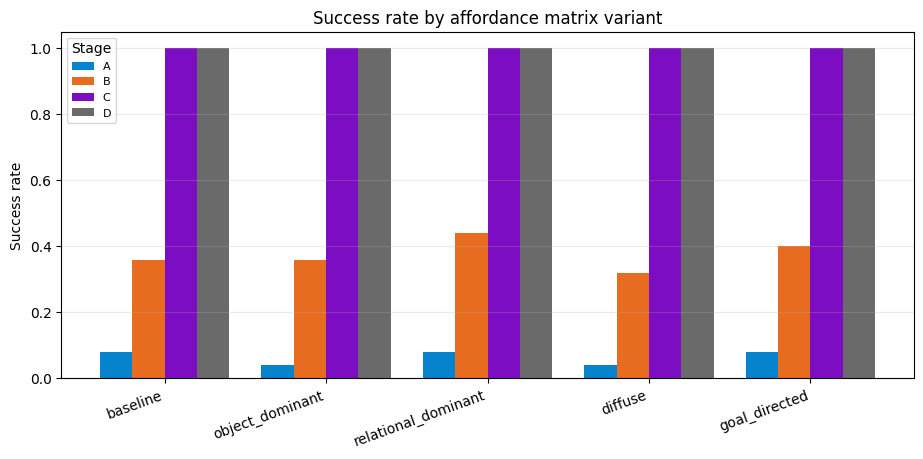

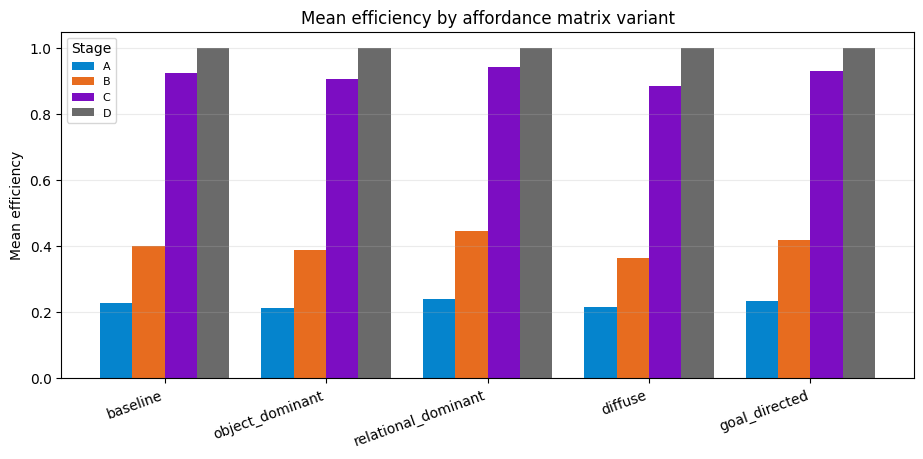

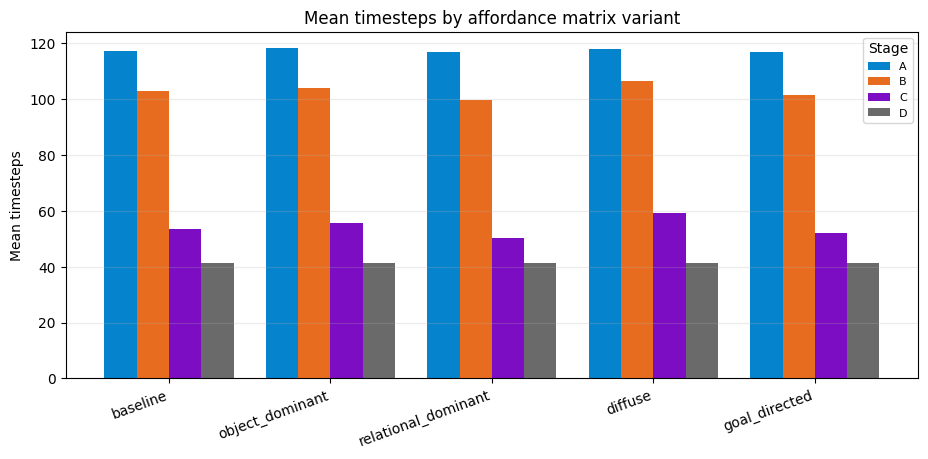

In [15]:
plot_metric_by_stage(summary, VARIANTS, STAGE_NAMES, "success_rate", "Success rate")
plot_metric_by_stage(summary, VARIANTS, STAGE_NAMES, "mean_efficiency", "Mean efficiency")
plot_metric_by_stage(summary, VARIANTS, STAGE_NAMES, "mean_timesteps", "Mean timesteps")

## Example Trajectories

2D path taken by the object during trial 0 for each affordance variant, all run with **stage C** developmental parameters.

Timesteps: closer dots = faster movement, sparse dots = slower

| Path Pattern | Meaning |
|---|---|
| **Straight shot** | Variant produces feedforward control; agent commits confidently to goal |
| **Circuitous/curved** | Agent explores or corrects trajectory; less stable control or more reactive |
| **Loops/backtracking** | Agent overshoots or oscillates; poor damping or unstable error correction |
| **Slow approach** (many dots) | Task took many steps; might indicate hesitation or inefficient planning |
| **All paths converge** | All variants succeed but with different efficiencies |
| **Some paths miss goal** | Variant produces systematic errors; goal outside reachable space or tolerance |

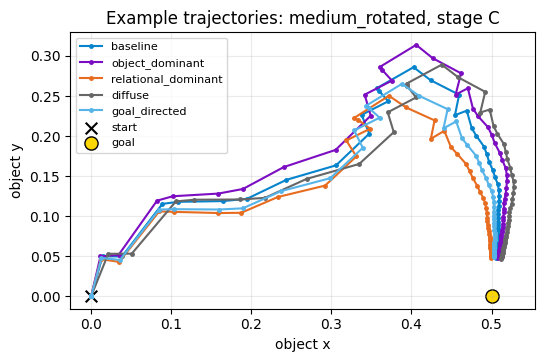

In [16]:
plot_example_trajectories(examples, VARIANTS, "C", EXPERIMENT_TASK)